# Exploratory Data Analysis
Explore the dataset, check distributions, class balance, and correlations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/raw_data.csv')
print(df.shape)
df.head()

(1000000, 20)


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [35]:
print(df.shape)
print(df.dtypes)
# print(df.head())



(1000000, 20)
age                       int64
gender                   object
academic_year             int64
study_hours_per_day     float64
exam_pressure           float64
academic_performance    float64
stress_level            float64
anxiety_score           float64
depression_score        float64
sleep_hours             float64
physical_activity       float64
social_support          float64
screen_time             float64
internet_usage          float64
financial_stress        float64
family_expectation      float64
burnout_score           float64
mental_health_index     float64
risk_level               object
dropout_risk            float64
dtype: object


In [36]:
print(df.columns)


Index(['age', 'gender', 'academic_year', 'study_hours_per_day',
       'exam_pressure', 'academic_performance', 'stress_level',
       'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity',
       'social_support', 'screen_time', 'internet_usage', 'financial_stress',
       'family_expectation', 'burnout_score', 'mental_health_index',
       'risk_level', 'dropout_risk'],
      dtype='object')


In [37]:
print(df.isnull().sum())
print(f"Duplicates: {df.duplicated().sum()}")

age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
dtype: int64
Duplicates: 0


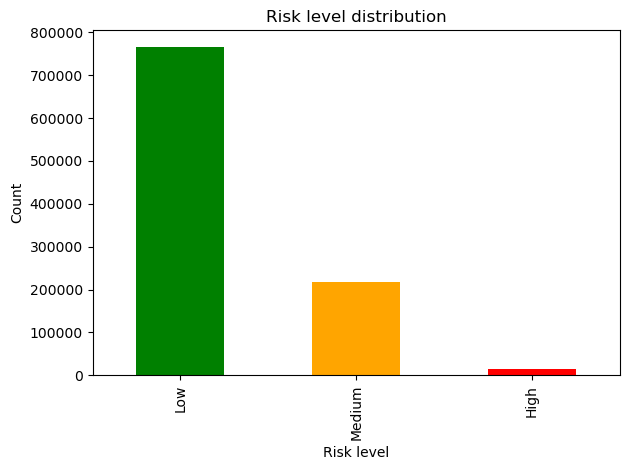

risk_level
Low       76.7
Medium    21.8
High       1.5
Name: proportion, dtype: float64


In [38]:
df['risk_level'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('Risk level distribution')
plt.xlabel('Risk level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Also print percentages
print(df['risk_level'].value_counts(normalize=True).mul(100).round(1))

In [ ]:
print(df['risk_level'].value_counts())
print(df['risk_level'].unique())

risk_level
Low       766645
Medium    218275
High       15080
Name: count, dtype: int64
['Low' 'High' 'Medium']


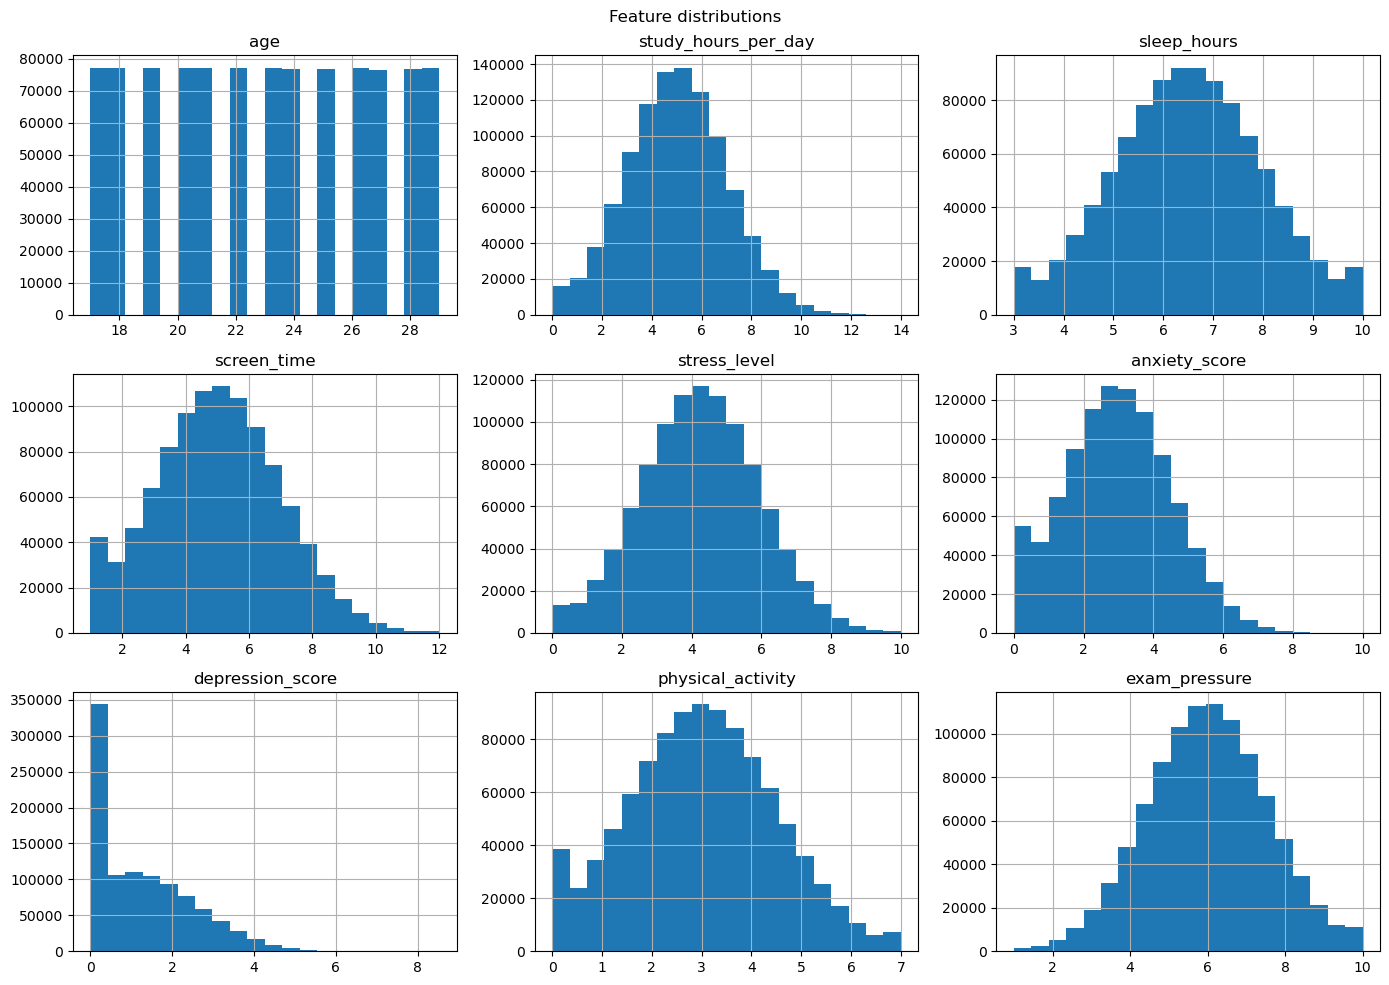

In [39]:
numeric_cols = ['age', 'study_hours_per_day', 'sleep_hours', 'screen_time',
                'stress_level', 'anxiety_score', 'depression_score',
                'physical_activity', 'exam_pressure']

df[numeric_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle('Feature distributions')
plt.tight_layout()
plt.show()

In [ ]:
df['risk_level_encoded'] = df['risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

plt.figure(figsize=(14, 10))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.title('Full correlation heatmap')
plt.tight_layout()
plt.show()

                  burnout_score  depression_score  risk_level
burnout_score          1.000000          0.642612    0.828259
depression_score       0.642612          1.000000    0.532063
risk_level             0.828259          0.532063    1.000000


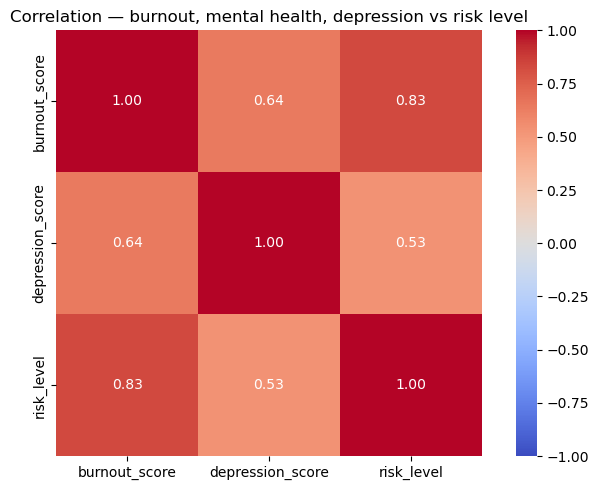

In [26]:
# Visual heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True
)
plt.title('Correlation — burnout, mental health, depression vs risk level')
plt.tight_layout()
plt.show()

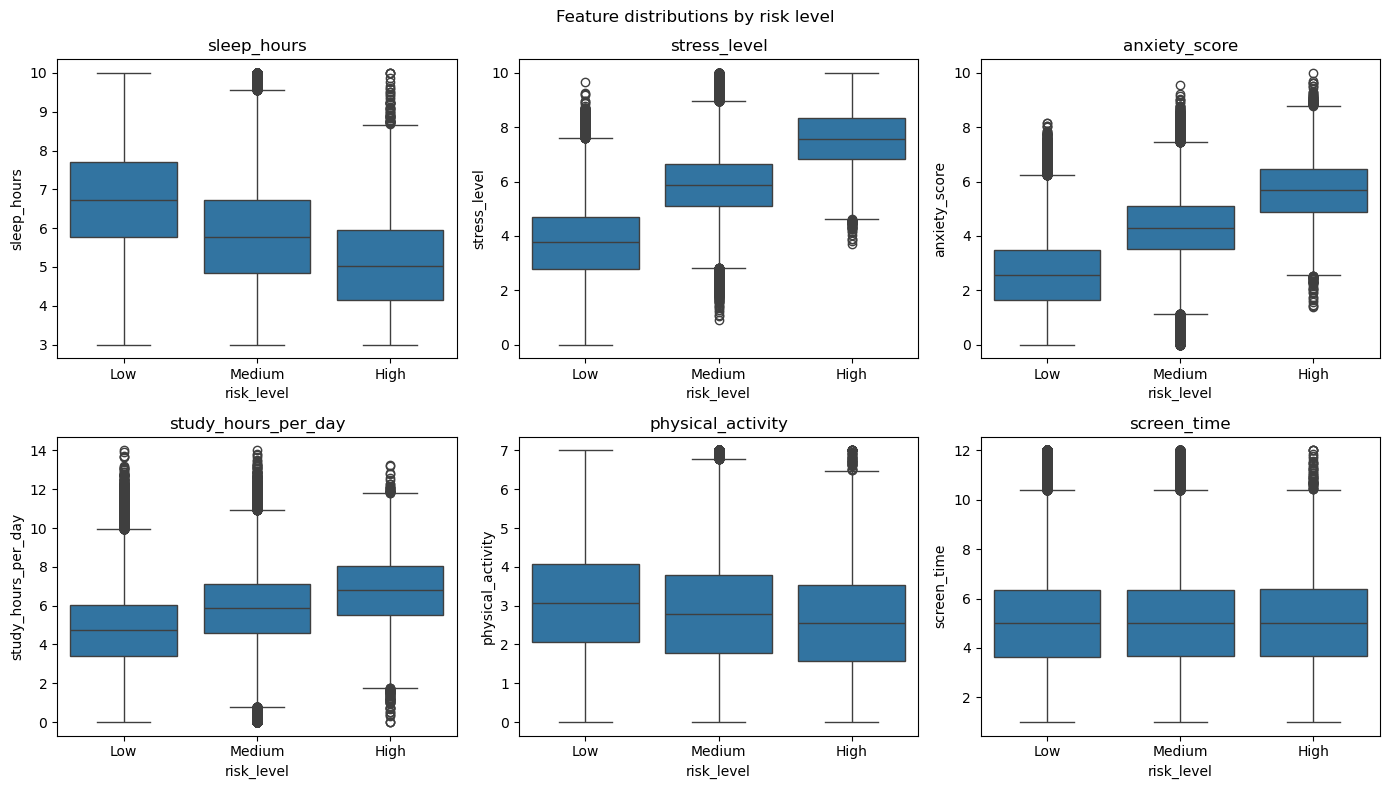

In [40]:
key_features = ['sleep_hours', 'stress_level', 'anxiety_score',
                'study_hours_per_day', 'physical_activity', 'screen_time']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x='risk_level', y=col,
                order=['Low', 'Medium', 'High'], ax=ax)
    ax.set_title(col)
plt.suptitle('Feature distributions by risk level')
plt.tight_layout()
plt.show()

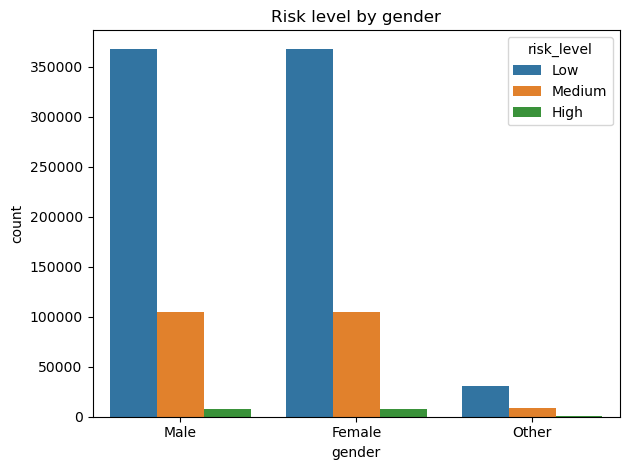

In [41]:
sns.countplot(data=df, x='gender', hue='risk_level',
              hue_order=['Low', 'Medium', 'High'])
plt.title('Risk level by gender')
plt.tight_layout()
plt.show()

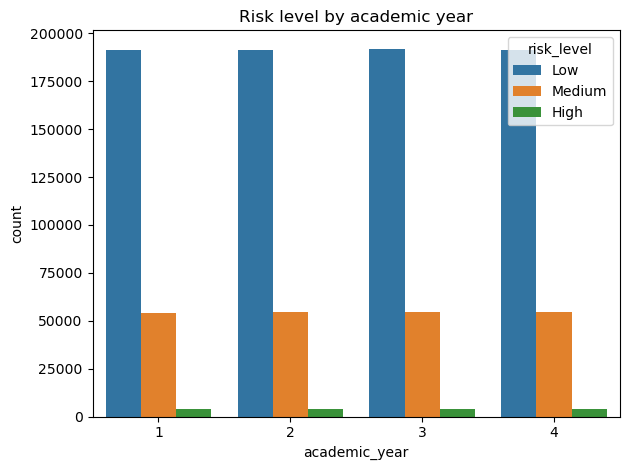

In [42]:
sns.countplot(data=df, x='academic_year', hue='risk_level',
              hue_order=['Low', 'Medium', 'High'])
plt.title('Risk level by academic year')
plt.tight_layout()
plt.show()

In [43]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print("Outliers per column:")
print(outliers)

Outliers per column:
age                       0
study_hours_per_day    3491
sleep_hours               0
screen_time            3507
stress_level           3287
anxiety_score          3409
depression_score       3351
physical_activity         0
exam_pressure          2809
dtype: int64


In [44]:
print(df.groupby('risk_level')[key_features].mean().round(2))

            sleep_hours  stress_level  anxiety_score  study_hours_per_day  \
risk_level                                                                  
High               5.09          7.58           5.67                 6.77   
Low                6.73          3.71           2.56                 4.72   
Medium             5.79          5.88           4.30                 5.86   

            physical_activity  screen_time  
risk_level                                  
High                     2.57         5.03  
Low                      3.08         5.02  
Medium                   2.80         5.02  


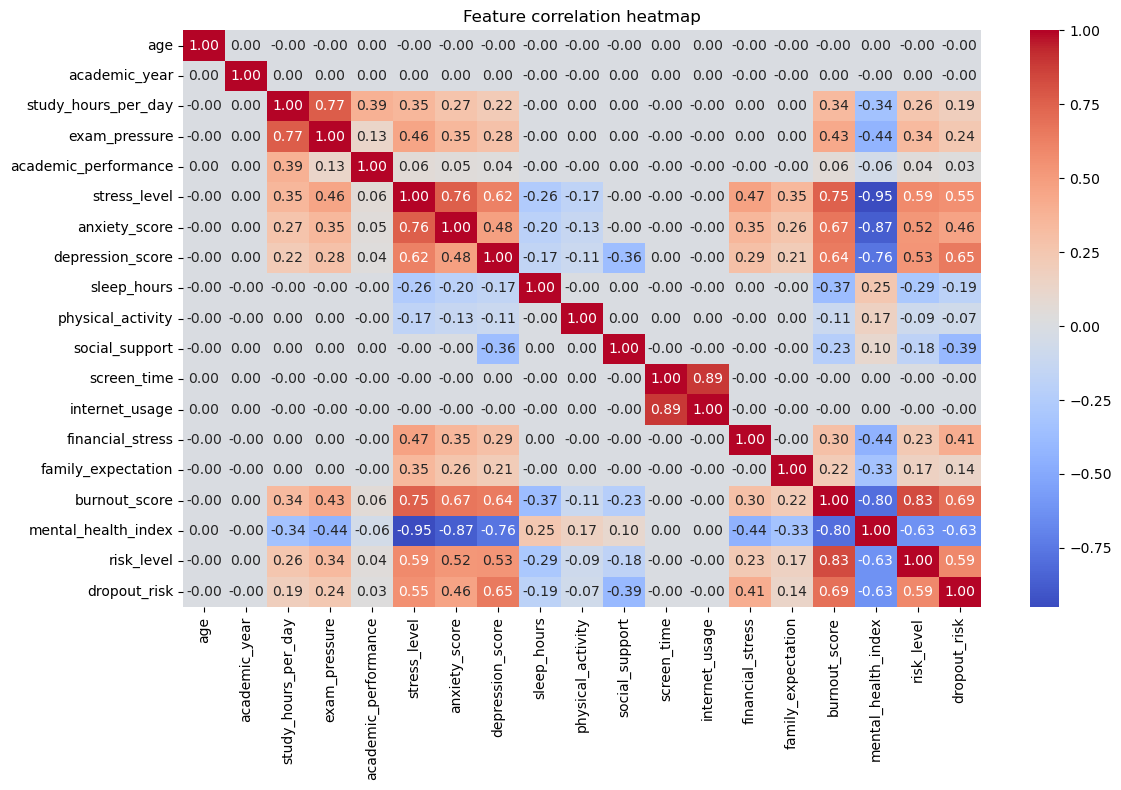

In [20]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.show()

In [ ]:

df_temp = df.copy()
df_temp['risk_level_encoded'] = df_temp['risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

for col in ['gender', 'academic_year']:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

# Drop leakage suspects and the raw target
drop_cols = ['risk_level', 'burnout_score', 'mental_health_index', 'dropout_risk']
feature_cols = [c for c in df_temp.select_dtypes(include='number').columns
                if c not in drop_cols + ['risk_level_encoded']]

X = df_temp[feature_cols]
y = df_temp['risk_level_encoded']


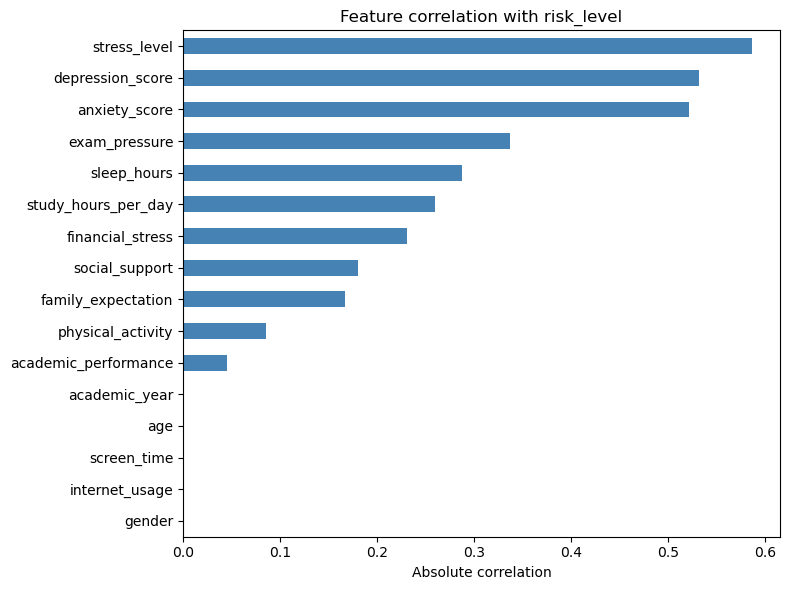

stress_level            0.586117
depression_score        0.532063
anxiety_score           0.521974
exam_pressure           0.336580
sleep_hours             0.287203
study_hours_per_day     0.260212
financial_stress        0.231053
social_support          0.180818
family_expectation      0.167409
physical_activity       0.085685
academic_performance    0.044945
academic_year           0.000650
age                     0.000618
screen_time             0.000417
internet_usage          0.000385
gender                  0.000115
dtype: float64


In [46]:
corr = X.corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
corr.plot(kind='barh', color='steelblue')
plt.title('Feature correlation with risk_level')
plt.xlabel('Absolute correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(corr)

In [49]:

# df_sample = df_temp.sample(frac=0.1, random_state=42)

# X_sample = df_sample[feature_cols]
# y_sample = df_sample['risk_level_encoded']


# rf = RandomForestClassifier(n_estimators=100, random_state=42)
# rf.fit(X, y)

# importance = pd.Series(rf.feature_importances_, index=feature_cols)
# importance = importance.sort_values(ascending=False)

# plt.figure(figsize=(8, 6))
# importance.plot(kind='barh', color='darkorange')
# plt.title('Random Forest feature importance')
# plt.xlabel('Importance score')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

# print(importance)

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# corr.plot(kind='barh', ax=axes[0], color='steelblue')
# axes[0].set_title('Correlation with target')
# axes[0].invert_yaxis()

# importance.plot(kind='barh', ax=axes[1], color='darkorange')
# axes[1].set_title('Random Forest importance')
# axes[1].invert_yaxis()

# plt.suptitle('Which features drive risk_level?')
# plt.tight_layout()
# plt.show()